# 6. Transfer Learning with Pre-Trained ResNet18

Previous approaches trained from scratch on ~5,000 samples — insufficient for models with 1M+ parameters. Transfer learning uses a model pre-trained on ImageNet (1.2M images) as a feature extractor, requiring far fewer task-specific samples.

Key changes:
1. **Pre-trained ResNet18** — frozen early layers, fine-tune later layers
2. **Focal Loss** — better than weighted cross-entropy for class imbalance; down-weights easy examples, focuses on hard ones
3. **Softer class balancing** — square root of inverse frequency instead of full inverse
4. **Pre-computed spectrograms** — faster training, reproducible augmentation

In [1]:
import sys
sys.path.append(r"E:\GitHub\lung-sound-classification")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import librosa
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
import torchvision.models as models

from src.config import *
from src.data_loader import patient_split
from src.evaluate import (
    evaluate_predictions, plot_confusion_matrix,
    plot_training_curves, compare_models, get_device
)

device = get_device()
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 6.1 Pre-Compute All Spectrograms
On-the-fly spectrogram generation is slow and makes debugging harder. We pre-compute all 3-channel spectrograms once, save them to disk, and load them as arrays. This also ensures validation/test spectrograms are deterministic.

In [2]:
CYCLE_DUR = 4.0
TARGET_LEN = int(CYCLE_DUR * SAMPLE_RATE)

cycle_df = pd.read_csv(DATA_DIR / 'cycle_dataset.csv')
cycle_df['label'] = cycle_df['label'].astype(int)
cycle_df['label_binary'] = (cycle_df['label'] > 0).astype(int)

train_df, val_df, test_df = patient_split(cycle_df)


def load_and_pad(row):
    """Load audio, pad/truncate to fixed length."""
    try:
        y, _ = librosa.load(row['audio_path'], sr=SAMPLE_RATE,
                            offset=row['start'], duration=row['end'] - row['start'])
    except:
        y = np.zeros(TARGET_LEN, dtype=np.float32)
    if len(y) < TARGET_LEN:
        y = np.pad(y, (0, TARGET_LEN - len(y)))
    else:
        y = y[:TARGET_LEN]
    return y


def make_3ch_spectrogram(y, sr=SAMPLE_RATE):
    """Create normalised 3-channel spectrogram."""
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    delta1 = librosa.feature.delta(log_mel, order=1)
    delta2 = librosa.feature.delta(log_mel, order=2)

    channels = []
    for ch in [log_mel, delta1, delta2]:
        m, s = ch.mean(), ch.std()
        channels.append((ch - m) / s if s > 0 else ch - m)
    return np.stack(channels, axis=0).astype(np.float32)


def precompute_spectrograms(df, desc="Computing"):
    specs, labels_4, labels_2 = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        y = load_and_pad(row)
        spec = make_3ch_spectrogram(y)
        specs.append(spec)
        labels_4.append(row['label'])
        labels_2.append(row['label_binary'])
    return np.array(specs), np.array(labels_4), np.array(labels_2)


# Check if already pre-computed
spec_path = DATA_DIR / 'spectrograms_3ch.npz'
if spec_path.exists():
    print("Loading pre-computed spectrograms...")
    data = np.load(spec_path)
    X_train, y_train_4, y_train_bin = data['X_train'], data['y_train_4'], data['y_train_bin']
    X_val, y_val_4, y_val_bin = data['X_val'], data['y_val_4'], data['y_val_bin']
    X_test, y_test_4, y_test_bin = data['X_test'], data['y_test_4'], data['y_test_bin']
else:
    print("Pre-computing spectrograms (this takes ~10 minutes)...")
    X_train, y_train_4, y_train_bin = precompute_spectrograms(train_df, "Train")
    X_val, y_val_4, y_val_bin = precompute_spectrograms(val_df, "Val")
    X_test, y_test_4, y_test_bin = precompute_spectrograms(test_df, "Test")

    np.savez(spec_path,
             X_train=X_train, y_train_4=y_train_4, y_train_bin=y_train_bin,
             X_val=X_val, y_val_4=y_val_4, y_val_bin=y_val_bin,
             X_test=X_test, y_test_4=y_test_4, y_test_bin=y_test_bin)
    print("Saved to disk.")

print(f"\nShapes: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")
print(f"4-class train distribution: {np.bincount(y_train_4)}")
print(f"Binary train distribution: {np.bincount(y_train_bin)}")

Split sizes — Train: 3809, Val: 1386, Test: 1703
Unique patients — Train: 81, Val: 19, Test: 26
Pre-computing spectrograms (this takes ~10 minutes)...


Test: 100%|██████████| 1703/1703 [00:15<00:00, 112.71it/s]


Saved to disk.

Shapes: Train=(3809, 3, 128, 173), Val=(1386, 3, 128, 173), Test=(1703, 3, 128, 173)
4-class train distribution: [2257  841  491  220]
Binary train distribution: [2257 1552]


## 6.2 Dataset with Augmentation
Augmentation is applied at the spectrogram level (SpecAugment) for speed. Audio-level augmentation was too slow with on-the-fly loading.

In [3]:
class SpectrogramDataset(Dataset):
    def __init__(self, specs, labels_4, labels_bin, augment=False):
        self.specs = torch.FloatTensor(specs)
        self.labels_4 = torch.LongTensor(labels_4)
        self.labels_bin = torch.LongTensor(labels_bin)
        self.augment = augment

    def __len__(self):
        return len(self.labels_4)

    def __getitem__(self, idx):
        spec = self.specs[idx].clone()
        if self.augment:
            spec = self._augment(spec)
        return spec, self.labels_4[idx], self.labels_bin[idx]

    @staticmethod
    def _augment(spec):
        c, h, w = spec.shape
        # Frequency masking
        if torch.rand(1) > 0.5:
            f = int(torch.randint(5, max(6, h // 5), (1,)))
            f0 = int(torch.randint(0, h - f, (1,)))
            spec[:, f0:f0+f, :] = 0
        # Time masking
        if torch.rand(1) > 0.5:
            t = int(torch.randint(5, max(6, w // 5), (1,)))
            t0 = int(torch.randint(0, w - t, (1,)))
            spec[:, :, t0:t0+t] = 0
        # Random gain
        if torch.rand(1) > 0.5:
            spec = spec * (0.8 + 0.4 * torch.rand(1))
        return spec


train_dataset = SpectrogramDataset(X_train, y_train_4, y_train_bin, augment=True)
val_dataset = SpectrogramDataset(X_val, y_val_4, y_val_bin, augment=False)
test_dataset = SpectrogramDataset(X_test, y_test_4, y_test_bin, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Batch check: {next(iter(train_loader))[0].shape}")

Batch check: torch.Size([32, 3, 128, 173])


## 6.3 Focal Loss
Standard cross-entropy treats all samples equally. With imbalanced data, the model gets overwhelmed by easy Normal examples. **Focal Loss** adds a modulating factor $(1-p_t)^\gamma$ that down-weights well-classified examples and focuses training on hard, misclassified ones.

- When $\gamma=0$: equivalent to standard cross-entropy
- When $\gamma=2$: a sample classified with 95% confidence has its loss reduced by 25×

This is more principled than aggressive class weights, which distort the loss landscape and cause the model to ignore the majority class entirely.

In [4]:
class FocalLoss(nn.Module):
    """Focal Loss with optional class weights."""
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha  # class weights tensor

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)  # probability of correct class
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


# Softer class weights: square root of inverse frequency
class_counts = np.bincount(y_train_4)
soft_weights = 1.0 / np.sqrt(class_counts.astype(float))
soft_weights = soft_weights / soft_weights.sum() * len(soft_weights)  # normalise to mean=1
soft_weights = torch.FloatTensor(soft_weights)

# Compare with old aggressive weights
aggressive_weights = compute_class_weight('balanced', classes=np.unique(y_train_4), y=y_train_4)

print("Class weight comparison:")
print(f"{'Class':<10} {'Aggressive':>12} {'Soft (sqrt)':>12}")
print("-" * 36)
for i, name in enumerate(CYCLE_CLASS_NAMES):
    print(f"{name:<10} {aggressive_weights[i]:>12.3f} {soft_weights[i]:>12.3f}")

Class weight comparison:
Class        Aggressive  Soft (sqrt)
------------------------------------
Normal            0.422        0.501
Crackle           1.132        0.821
Wheeze            1.939        1.074
Both              4.328        1.604


## 6.4 Transfer Learning: ResNet18
Using a **pre-trained ResNet18** as the backbone:
- **Frozen early layers** (conv1 through layer2): These capture generic visual features (edges, textures) that transfer well to spectrograms
- **Fine-tuned later layers** (layer3, layer4): These learn task-specific patterns
- **Custom classifier head**: Adapted for 4-class respiratory sound classification

The first convolutional layer is modified from 3→64 channels to accept our 3-channel spectrograms (mel + delta + delta-delta), which conveniently matches ImageNet's RGB input dimension.

In [5]:
class ResNet18Transfer(nn.Module):
    """Pre-trained ResNet18 with frozen early layers."""

    def __init__(self, num_classes=4, freeze_layers=True):
        super().__init__()

        # Load pre-trained ResNet18
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Keep the first conv layer (3 channels matches our mel+delta+delta2)
        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1  # 64 channels
        self.layer2 = backbone.layer2  # 128 channels
        self.layer3 = backbone.layer3  # 256 channels
        self.layer4 = backbone.layer4  # 512 channels

        # Freeze early layers
        if freeze_layers:
            for param in self.conv1.parameters():
                param.requires_grad = False
            for param in self.bn1.parameters():
                param.requires_grad = False
            for param in self.layer1.parameters():
                param.requires_grad = False
            for param in self.layer2.parameters():
                param.requires_grad = False
            print("Frozen: conv1, bn1, layer1, layer2")
            print("Trainable: layer3, layer4, classifier")

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


model_resnet = ResNet18Transfer(num_classes=4, freeze_layers=True).to(device)

total_params = sum(p.numel() for p in model_resnet.parameters())
trainable_params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")

Frozen: conv1, bn1, layer1, layer2
Trainable: layer3, layer4, classifier

Total params: 11,242,692
Trainable params: 10,559,620 (93.9%)


## 6.5 Training with Focal Loss

In [6]:
def train_with_focal(model, train_loader, val_loader, num_epochs=80,
                     lr=1e-4, class_weights=None, model_name="model",
                     patience=20, gamma=2.0, task='4class'):
    """Training loop with Focal Loss."""
    model = model.to(device)
    criterion = FocalLoss(gamma=gamma, alpha=class_weights.to(device) if class_weights is not None else None)

    # Only optimise trainable parameters
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimiser = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimiser, T_0=20, T_mult=2, eta_min=1e-6)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0

    label_idx = 1 if task == '4class' else 2  # index in batch tuple

    for epoch in range(num_epochs):
        # Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for batch in train_loader:
            specs = batch[0].to(device)
            labels = batch[label_idx].to(device)

            optimiser.zero_grad()
            outputs = model(specs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimiser.step()

            running_loss += loss.item() * specs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # Validate
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                specs = batch[0].to(device)
                labels = batch[label_idx].to(device)
                outputs = model(specs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * specs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= val_total
        val_acc = val_correct / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODELS_DIR / f"{model_name}_best.pt")
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or patience_counter == 0:
            print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
                  f"Train: {train_loss:.4f}/{train_acc:.4f}  "
                  f"Val: {val_loss:.4f}/{val_acc:.4f}  "
                  f"{'★' if patience_counter == 0 else ''}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print(f"\nBest val loss: {best_val_loss:.4f}, Best val acc: {best_val_acc:.4f}")
    return history

## 6.6 Train ResNet18 — 4-Class

  Training ResNet18 Transfer — 4-Class (Focal Loss)
Epoch [  1/80] Train: 0.4214/0.3891  Val: 0.5306/0.4120  ★
Epoch [  5/80] Train: 0.1732/0.6311  Val: 0.9671/0.4127  
Epoch [ 10/80] Train: 0.0845/0.8026  Val: 1.2330/0.4596  
Epoch [ 15/80] Train: 0.0399/0.8945  Val: 1.4147/0.4473  
Epoch [ 20/80] Train: 0.0303/0.9231  Val: 1.4131/0.4416  

Early stopping at epoch 21

Best val loss: 0.5306, Best val acc: 0.4120
  Saved: E:\GitHub\lung-sound-classification\outputs\figures\resnet18_4class_curves.png


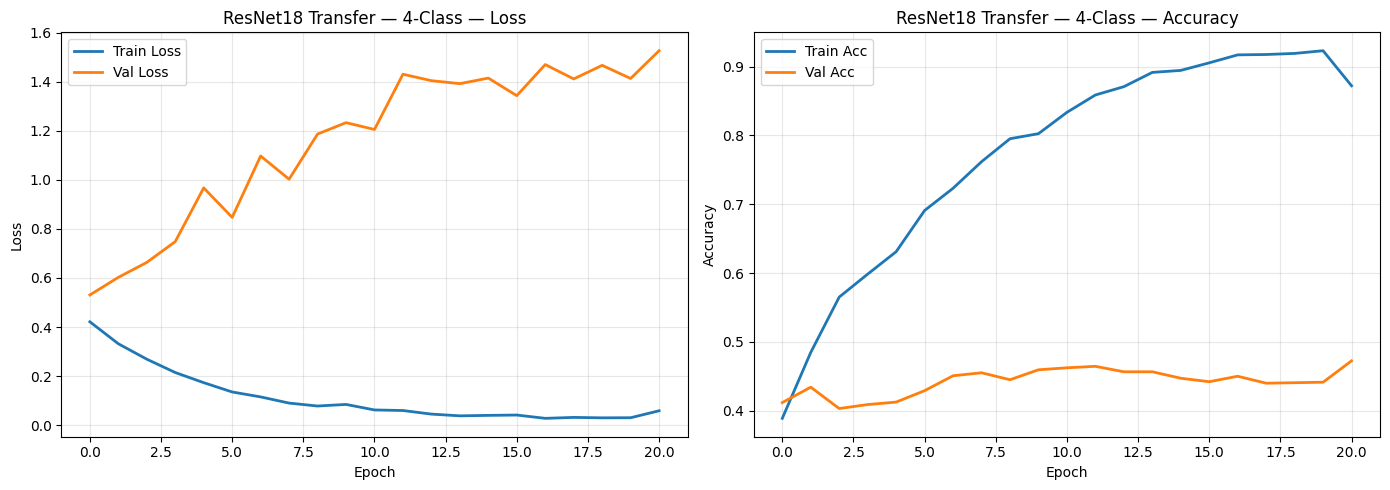


  ResNet18 — 4-Class
  Accuracy:          0.3629
  F1 (macro):        0.2925
  F1 (weighted):     0.3625

              precision    recall  f1-score   support

      Normal       0.58      0.30      0.39       800
     Crackle       0.38      0.58      0.46       517
      Wheeze       0.16      0.29      0.21       224
        Both       0.13      0.09      0.11       162

    accuracy                           0.36      1703
   macro avg       0.31      0.31      0.29      1703
weighted avg       0.42      0.36      0.36      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_resnet18_4class.png


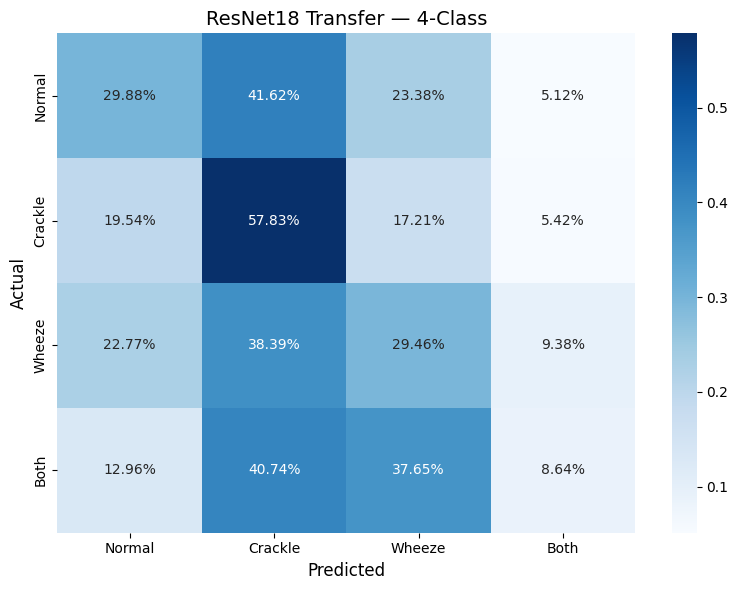

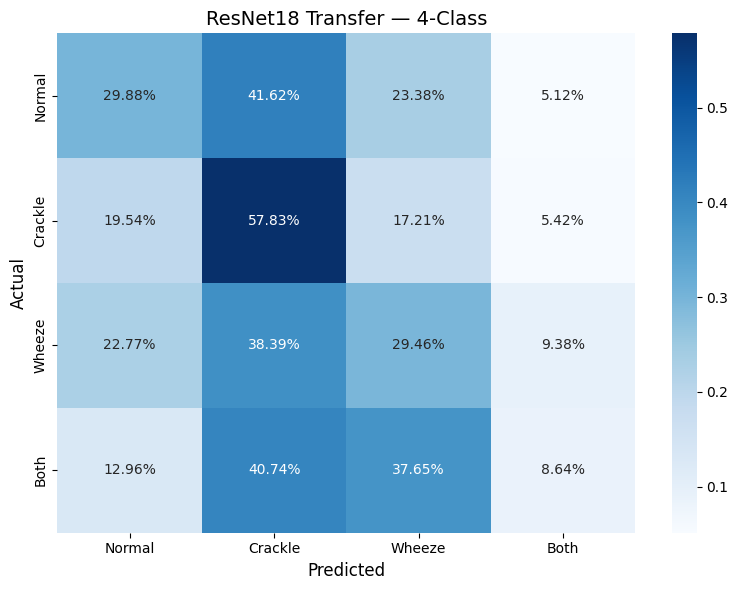

In [7]:
print("=" * 60)
print("  Training ResNet18 Transfer — 4-Class (Focal Loss)")
print("=" * 60)

resnet_history = train_with_focal(
    model_resnet, train_loader, val_loader,
    num_epochs=80, lr=1e-4, class_weights=soft_weights,
    model_name="resnet18_4class", patience=20, gamma=2.0, task='4class'
)

# Evaluate
model_resnet.load_state_dict(torch.load(MODELS_DIR / "resnet18_4class_best.pt", map_location=device))
plot_training_curves(resnet_history, title="ResNet18 Transfer — 4-Class",
                     save_path=FIGURES_DIR / "resnet18_4class_curves.png")

model_resnet.eval()
y_true_r, y_pred_r = [], []
with torch.no_grad():
    for batch in test_loader:
        specs = batch[0].to(device)
        labels = batch[1]
        outputs = model_resnet(specs)
        _, predicted = outputs.max(1)
        y_true_r.extend(labels.numpy())
        y_pred_r.extend(predicted.cpu().numpy())

y_true_r, y_pred_r = np.array(y_true_r), np.array(y_pred_r)
resnet_4class_results = evaluate_predictions(y_true_r, y_pred_r, title="ResNet18 — 4-Class")
plot_confusion_matrix(y_true_r, y_pred_r, title="ResNet18 Transfer — 4-Class",
                      save_path=FIGURES_DIR / "cm_resnet18_4class.png")

## 6.7 Train ResNet18 — Binary (Normal vs Abnormal)

Binary soft weights: Normal=0.907, Abnormal=1.093
Frozen: conv1, bn1, layer1, layer2
Trainable: layer3, layer4, classifier

  Training ResNet18 Transfer — Binary (Focal Loss)
Epoch [  1/80] Train: 0.1942/0.5547  Val: 0.1713/0.5801  ★
Epoch [  5/80] Train: 0.1094/0.7965  Val: 0.2093/0.6003  
Epoch [ 10/80] Train: 0.0499/0.9215  Val: 0.6280/0.5830  
Epoch [ 15/80] Train: 0.0262/0.9632  Val: 0.7276/0.5685  
Epoch [ 20/80] Train: 0.0194/0.9735  Val: 0.7612/0.5628  

Early stopping at epoch 21

Best val loss: 0.1713, Best val acc: 0.5801
  Saved: E:\GitHub\lung-sound-classification\outputs\figures\resnet18_binary_curves.png


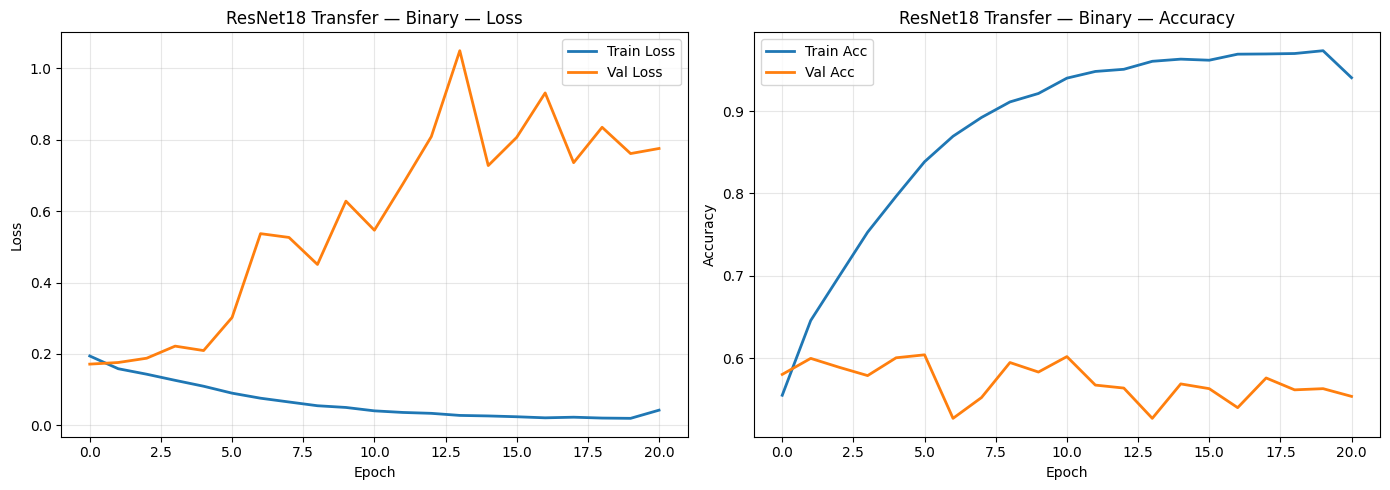


  ResNet18 — Binary
  Accuracy:          0.5755
  F1 (macro):        0.5583
  F1 (weighted):     0.5635

              precision    recall  f1-score   support

      Normal       0.57      0.40      0.47       800
    Abnormal       0.58      0.73      0.65       903

    accuracy                           0.58      1703
   macro avg       0.57      0.57      0.56      1703
weighted avg       0.57      0.58      0.56      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_resnet18_binary.png


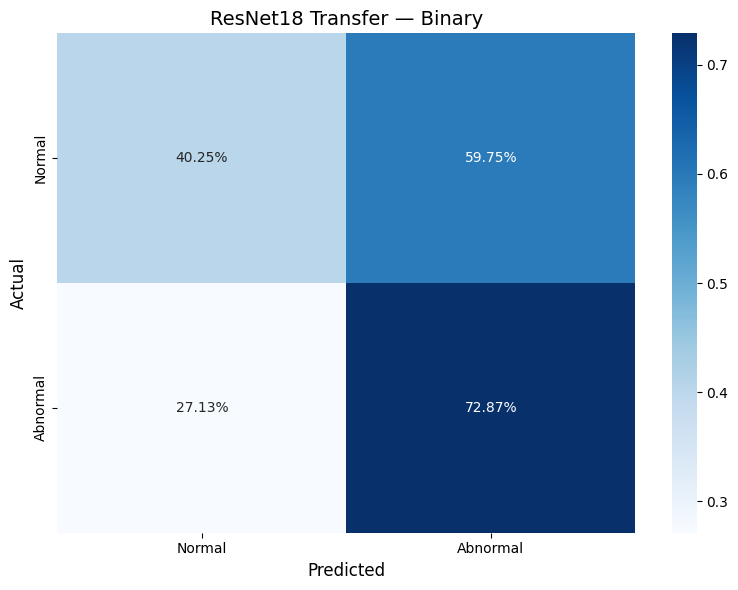

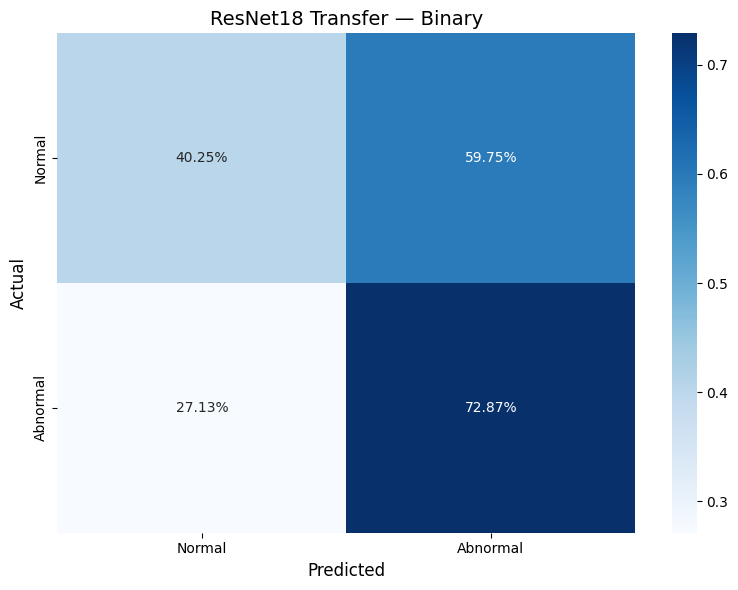

In [8]:
# Binary weights (soft)
bin_counts = np.bincount(y_train_bin)
soft_bin_weights = 1.0 / np.sqrt(bin_counts.astype(float))
soft_bin_weights = soft_bin_weights / soft_bin_weights.sum() * 2
soft_bin_weights = torch.FloatTensor(soft_bin_weights)
print(f"Binary soft weights: Normal={soft_bin_weights[0]:.3f}, Abnormal={soft_bin_weights[1]:.3f}")

model_binary = ResNet18Transfer(num_classes=2, freeze_layers=True).to(device)

print("\n" + "=" * 60)
print("  Training ResNet18 Transfer — Binary (Focal Loss)")
print("=" * 60)

binary_history = train_with_focal(
    model_binary, train_loader, val_loader,
    num_epochs=80, lr=1e-4, class_weights=soft_bin_weights,
    model_name="resnet18_binary", patience=20, gamma=2.0, task='binary'
)

# Evaluate
model_binary.load_state_dict(torch.load(MODELS_DIR / "resnet18_binary_best.pt", map_location=device))
plot_training_curves(binary_history, title="ResNet18 Transfer — Binary",
                     save_path=FIGURES_DIR / "resnet18_binary_curves.png")

model_binary.eval()
y_true_b, y_pred_b = [], []
with torch.no_grad():
    for batch in test_loader:
        specs = batch[0].to(device)
        labels = batch[2]
        outputs = model_binary(specs)
        _, predicted = outputs.max(1)
        y_true_b.extend(labels.numpy())
        y_pred_b.extend(predicted.cpu().numpy())

y_true_b, y_pred_b = np.array(y_true_b), np.array(y_pred_b)
resnet_binary_results = evaluate_predictions(
    y_true_b, y_pred_b, class_names=["Normal", "Abnormal"],
    title="ResNet18 — Binary"
)
plot_confusion_matrix(y_true_b, y_pred_b, class_names=["Normal", "Abnormal"],
                      title="ResNet18 Transfer — Binary",
                      save_path=FIGURES_DIR / "cm_resnet18_binary.png")

## 6.8 Ensemble: ML + DL
Combine the SVM (best ML model by accuracy) with ResNet18 (best DL model) via soft voting. The ML model uses handcrafted features while the DL model uses spectrograms — their errors are likely to be uncorrelated, making ensemble predictions more robust.


  Ensemble (SVM + ResNet18)
  Accuracy:          0.4991
  F1 (macro):        0.3164
  F1 (weighted):     0.4532

              precision    recall  f1-score   support

      Normal       0.52      0.77      0.62       800
     Crackle       0.51      0.40      0.45       517
      Wheeze       0.28      0.14      0.19       224
        Both       0.05      0.01      0.01       162

    accuracy                           0.50      1703
   macro avg       0.34      0.33      0.32      1703
weighted avg       0.44      0.50      0.45      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_ensemble.png


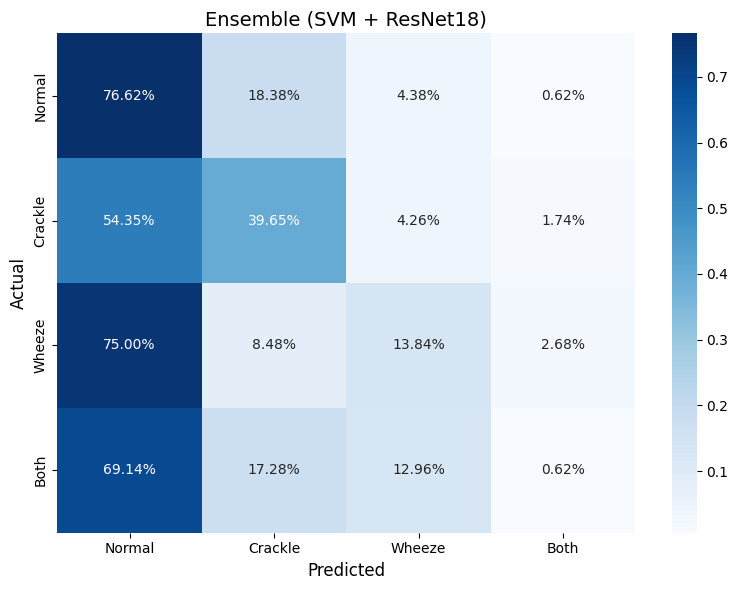

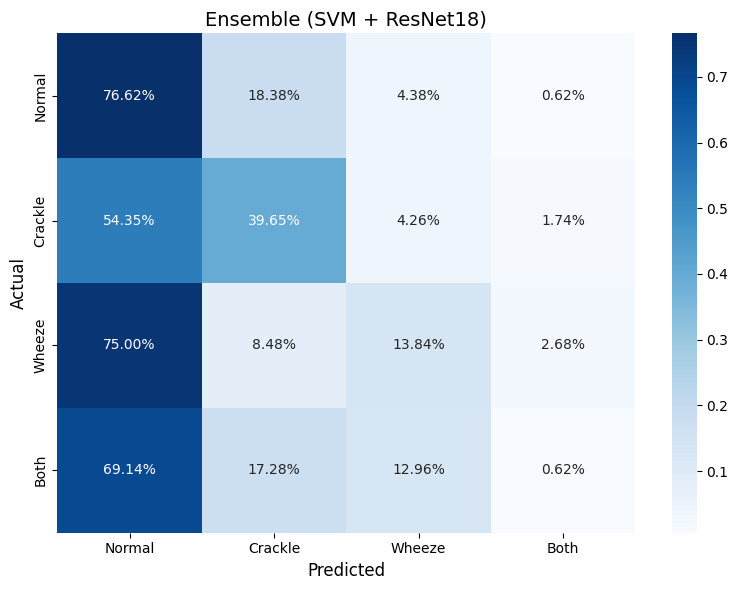

In [12]:
import joblib

# Load ML model and scaler
scaler = joblib.load(MODELS_DIR / 'scaler.joblib')
best_ml = joblib.load(MODELS_DIR / 'best_ml_model.joblib')

# Get ML predictions on handcrafted features
hc_data = np.load(DATA_DIR / 'handcrafted_features.npz')
X_test_scaled = scaler.transform(hc_data['X_test'])
y_pred_ml = best_ml.predict(X_test_scaled)
y_test_ml = hc_data['y_test']

# Get DL probabilities
model_resnet.eval()
dl_probs = []
with torch.no_grad():
    for batch in test_loader:
        specs = batch[0].to(device)
        outputs = model_resnet(specs)
        probs = F.softmax(outputs, dim=1)
        dl_probs.extend(probs.cpu().numpy())
dl_probs = np.array(dl_probs)

# Get ML probabilities (if SVM has predict_proba, otherwise use decision function)
try:
    ml_probs = best_ml.predict_proba(X_test_scaled)
except:
    # SVM without probability — use one-hot predictions
    ml_probs = np.zeros((len(y_pred_ml), 4))
    for i, pred in enumerate(y_pred_ml):
        ml_probs[i, pred] = 1.0

# Ensemble: weighted average (give DL slightly more weight)
ensemble_probs = 0.4 * ml_probs + 0.6 * dl_probs
y_pred_ensemble = np.argmax(ensemble_probs, axis=1)

ensemble_results = evaluate_predictions(
    y_test_ml, y_pred_ensemble, title="Ensemble (SVM + ResNet18)"
)
plot_confusion_matrix(
    y_test_ml, y_pred_ensemble, title="Ensemble (SVM + ResNet18)",
    save_path=FIGURES_DIR / "cm_ensemble.png"
)

## 6.9 Comprehensive Final Comparison

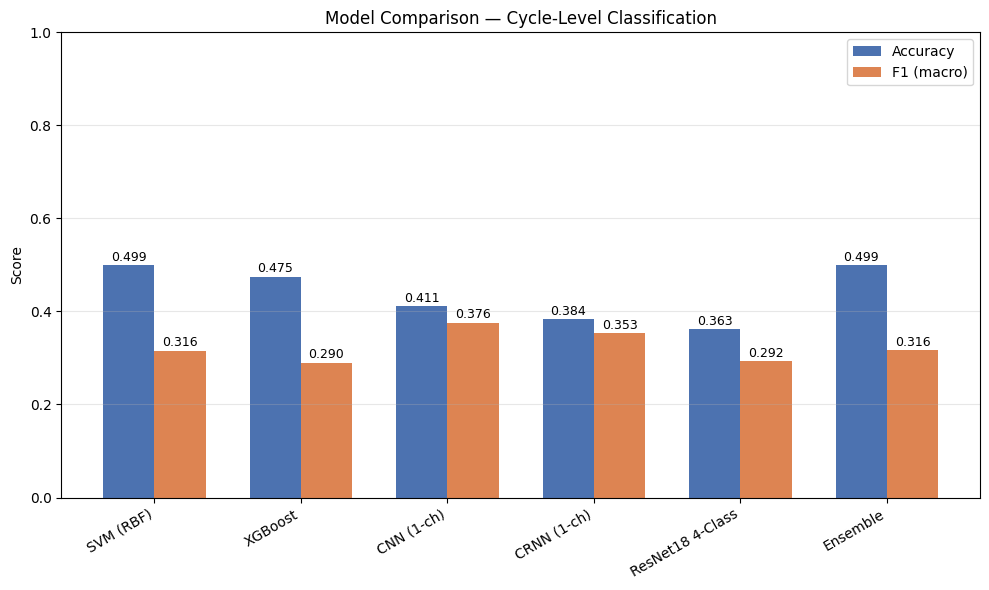


  FINAL COMPREHENSIVE RESULTS

--- 4-Class (Normal / Crackle / Wheeze / Both) ---
Model                      Accuracy   F1 (macro)
------------------------------------------------
SVM (RBF)                    0.4990       0.3160
XGBoost                      0.4750       0.2900
CNN (1-ch)                   0.4110       0.3760
CRNN (1-ch)                  0.3840       0.3530
ResNet18 4-Class             0.3629       0.2925
Ensemble                     0.4991       0.3164

--- Binary (Normal vs Abnormal) ---
ResNet18 Binary              0.5755       0.5583


In [10]:
all_results = {
    "SVM (RBF)": {"accuracy": 0.499, "f1_macro": 0.316},
    "XGBoost": {"accuracy": 0.475, "f1_macro": 0.290},
    "CNN (1-ch)": {"accuracy": 0.411, "f1_macro": 0.376},
    "CRNN (1-ch)": {"accuracy": 0.384, "f1_macro": 0.353},
    "ResNet18 4-Class": resnet_4class_results,
    "Ensemble": ensemble_results,
}

compare_models(all_results, save_path=FIGURES_DIR / "final_comprehensive_comparison.png")

print("\n" + "=" * 70)
print("  FINAL COMPREHENSIVE RESULTS")
print("=" * 70)
print(f"\n--- 4-Class (Normal / Crackle / Wheeze / Both) ---")
print(f"{'Model':<24} {'Accuracy':>10} {'F1 (macro)':>12}")
print("-" * 48)
for name, res in all_results.items():
    print(f"{name:<24} {res['accuracy']:>10.4f} {res['f1_macro']:>12.4f}")

print(f"\n--- Binary (Normal vs Abnormal) ---")
print(f"{'ResNet18 Binary':<24} {resnet_binary_results['accuracy']:>10.4f} {resnet_binary_results['f1_macro']:>12.4f}")